In [ ]:
!pip install transformers datasets evaluate safetensors nest_asyncio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.


In [ ]:
import torch
import gc

# Clear CUDA cache
torch.cuda.empty_cache()

# Collect unused memory from Python garbage collector
gc.collect()

# Optional: check available memory after clearing
!nvidia-smi

Fri Mar 28 09:00:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   51C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from huggingface_hub import notebook_login
notebook_login()


In [ ]:
!pip install evaluate


In [ ]:
import nest_asyncio
nest_asyncio.apply()  # Enable nested event loops for Colab/Streamlit

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate
from datasets import Dataset, Value
import json

# --------------------------
# CONFIGURATIONS
# --------------------------
CSV_PATH = "/content/drive/MyDrive/0dataset/cleaned D.csv"  # Path to your dataset CSV
XLMR_CHECKPOINT = "xlm-roberta-large"      # XLM-RoBERTa-large checkpoint
MBERT_CHECKPOINT = "bert-base-multilingual-cased"  # mBERT checkpoint
LOCAL_OUTPUT_DIR = "/content/checkpoints"  # For intermediate checkpoints
FINAL_OUTPUT_DIR = "/content/drive/MyDrive/Your_Path"  # Final model save path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

NUM_LABELS = 5

label2id = {
    "Normal": 0,
    "Happy": 1,
    "Stressed": 2,
    "Moderately Depressed": 3,
    "Severely Depressed": 4
}
id2label = {v: k for k, v in label2id.items()}

# --------------------------
# DATA PREPARATION
# --------------------------
# Load CSV and drop rows with missing captions
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["caption"])
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # Shuffle dataset
df["labels"] = df["state"].map(label2id)
df = df.dropna(subset=["labels"])  # Remove rows with NaN labels


# Split into train/test (80/20 split)
split_idx = int(0.8 * len(df))
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

# Create Hugging Face Datasets (only using "caption" and "labels")
train_dataset = Dataset.from_pandas(train_df[["caption", "labels"]])
test_dataset  = Dataset.from_pandas(test_df[["caption", "labels"]])

# --------------------------
# TOKENIZATION
# --------------------------
tokenizer_xlmr = AutoTokenizer.from_pretrained(XLMR_CHECKPOINT)
tokenizer_mbert = AutoTokenizer.from_pretrained(MBERT_CHECKPOINT)
if tokenizer_mbert.pad_token is None:
    tokenizer_mbert.pad_token = tokenizer_mbert.eos_token

def tokenize_function(examples):
    # Ensure the input is a list of strings
    captions = list(examples["caption"])

    # Tokenize for XLM-RoBERTa
    xlmr_enc = tokenizer_xlmr(
        captions,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # Tokenize for mBERT
    mbert_enc = tokenizer_mbert(
        captions,
        truncation=True,
        padding="max_length",
        max_length=128
    )

    return {
        "xlmr_input_ids": xlmr_enc["input_ids"],
        "xlmr_attention_mask": xlmr_enc["attention_mask"],
        "mbert_input_ids": mbert_enc["input_ids"],
        "mbert_attention_mask": mbert_enc["attention_mask"],
        "labels": examples["labels"]
    }

def prepare_dataset(dataset):
    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.remove_columns(["caption"])
    # Cast "labels" to int64 (using datasets' Value type) for CrossEntropyLoss
    dataset = dataset.cast_column("labels", Value("int64"))
    cols = ["xlmr_input_ids", "xlmr_attention_mask", "mbert_input_ids", "mbert_attention_mask", "labels"]
    dataset.set_format("torch", columns=cols)
    return dataset

train_dataset = prepare_dataset(train_dataset)
test_dataset = prepare_dataset(test_dataset)

# --------------------------
# CUSTOM DATA COLLATOR
# --------------------------
def data_collator(features):
    batch = {}
    for key in features[0].keys():
        if key == "labels":
            # Ensure that each label is a scalar integer.
            batch[key] = torch.tensor([int(f[key].squeeze()) for f in features], dtype=torch.long)
        else:
            batch[key] = torch.stack([f[key] for f in features])
    return batch


# --------------------------
# FUSION MODEL DEFINITION
# --------------------------
class FusionClassifier(nn.Module):
    def __init__(self, xlmr_checkpoint, mbert_checkpoint, num_labels=5, dropout_rate=0.1):
        super(FusionClassifier, self).__init__()
        # Load both models (both will be fine-tuned)
        self.xlmr = AutoModel.from_pretrained(xlmr_checkpoint)
        self.mbert = AutoModel.from_pretrained(mbert_checkpoint)

        # Transform the XLM-R [CLS] embedding (learned projection)
        self.fc1 = nn.Linear(self.xlmr.config.hidden_size, self.xlmr.config.hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        # Fusion: concatenate transformed XLM-R and mBERT features
        combined_size = self.xlmr.config.hidden_size + self.mbert.config.hidden_size
        self.fc2 = nn.Linear(combined_size, num_labels)

    def forward(self, xlmr_input_ids, xlmr_attention_mask, mbert_input_ids, mbert_attention_mask, labels=None):
        # XLM-R branch: fine-tune on caption embeddings
        xlmr_outputs = self.xlmr(input_ids=xlmr_input_ids, attention_mask=xlmr_attention_mask)
        xlmr_cls = xlmr_outputs.last_hidden_state[:, 0, :]  # Use [CLS] token representation
        transformed_xlmr = self.relu(self.fc1(xlmr_cls))

        # mBERT branch: fine-tune for classification
        mbert_outputs = self.mbert(input_ids=mbert_input_ids, attention_mask=mbert_attention_mask)
        mbert_mean = torch.mean(mbert_outputs.last_hidden_state, dim=1)  # Mean pooling

        # Fusion: concatenate both representations
        fused = torch.cat([transformed_xlmr, mbert_mean], dim=1)
        fused = self.dropout(fused)
        logits = self.fc2(fused)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)
            return {"loss": loss, "logits": logits}
        return {"logits": logits}

# Instantiate the fusion model
fusion_model = FusionClassifier(XLMR_CHECKPOINT, MBERT_CHECKPOINT, NUM_LABELS)

# --------------------------
# METRIC DEFINITION
# --------------------------
metric_accuracy = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")
metric_precision = evaluate.load("precision")
metric_recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_accuracy.compute(predictions=preds, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=preds, references=labels, average="macro")["f1"]
    precision = metric_precision.compute(predictions=preds, references=labels, average="macro")["precision"]
    recall = metric_recall.compute(predictions=preds, references=labels, average="macro")["recall"]
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# --------------------------
# TRAINING ARGUMENTS & TRAINER
# --------------------------
training_args = TrainingArguments(
    output_dir=LOCAL_OUTPUT_DIR,
    eval_strategy="epoch",  # Using eval_strategy (evaluation_strategy is deprecated)
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_steps=100,
    seed=SEED,
    dataloader_num_workers=2,
    report_to="none",
    learning_rate=1e-5
)

trainer = Trainer(
    model=fusion_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# --------------------------
# TRAINING
# --------------------------
trainer.train()

# --------------------------
# FINAL EVALUATION
# --------------------------
final_metrics = trainer.evaluate(test_dataset)
print("\nFinal evaluation on test set:")
print(final_metrics)

# --------------------------
# SAVE MODEL & TOKENIZERS
# --------------------------
os.makedirs(FINAL_OUTPUT_DIR, exist_ok=True)

from safetensors.torch import save_file
save_file(fusion_model.state_dict(), os.path.join(FINAL_OUTPUT_DIR, "model.safetensors"))

# Save both tokenizers (for inference)
tokenizer_xlmr.save_pretrained(FINAL_OUTPUT_DIR)
tokenizer_mbert.save_pretrained(FINAL_OUTPUT_DIR)

print(f"Final fusion model saved to: {FINAL_OUTPUT_DIR}")

# --------------------------
# SAVE CUSTOM CONFIG FILE
# --------------------------
fusion_config = {
  "_name_or_path": "xlm_bert_mental_state_classifier",
  "model_type": "fusion_classifier",
  "num_labels": NUM_LABELS,
  "xlmr_checkpoint": XLMR_CHECKPOINT,
  "mbert_checkpoint": MBERT_CHECKPOINT,
  "xlmr_hidden_size": fusion_model.xlmr.config.hidden_size,
  "mbert_hidden_size": fusion_model.mbert.config.hidden_size,
  "combined_hidden_size": fusion_model.xlmr.config.hidden_size + fusion_model.mbert.config.hidden_size,
  "label2id": label2id,
  "id2label": id2label
}

with open(os.path.join(FINAL_OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(fusion_config, f, indent=2)

print("Custom fusion config saved!")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Casting the dataset:   0%|          | 0/2939 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.522800,1.435114,0.357605,0.354314,0.470742,0.356729
2,1.200900,1.129649,0.500170,0.492369,0.562849,0.500522
3,0.918100,0.811638,0.636951,0.633052,0.637615,0.638747
4,0.825400,0.675032,0.716230,0.716992,0.720321,0.716416
5,0.699200,0.825795,0.632868,0.633645,0.634761,0.633658
6,0.616900,0.601149,0.746853,0.747698,0.749267,0.746897
7,0.544100,0.607163,0.747873,0.748521,0.749365,0.748270
8,0.498500,0.559635,0.769650,0.769823,0.769954,0.769919
9,0.469500,0.550425,0.780878,0.780863,0.781060,0.781268
10,0.443000,0.543446,0.778836,0.779284,0.779766,0.779042



Final evaluation on test set:
{'eval_loss': 0.5504252910614014, 'eval_accuracy': 0.7808778496087104, 'eval_f1': 0.780863291389223, 'eval_precision': 0.7810596108670737, 'eval_recall': 0.7812677249897539, 'eval_runtime': 36.1826, 'eval_samples_per_second': 81.227, 'eval_steps_per_second': 2.543, 'epoch': 10.0}
Final fusion model saved to: /content/drive/MyDrive/subhu/model
Custom fusion config saved!


In [ ]:
!pip install transformers torch safetensors scikit-learn seaborn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 34.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

Accuracy: 0.8947
Precision: 0.8948
Recall: 0.8947
F1 Score: 0.8946


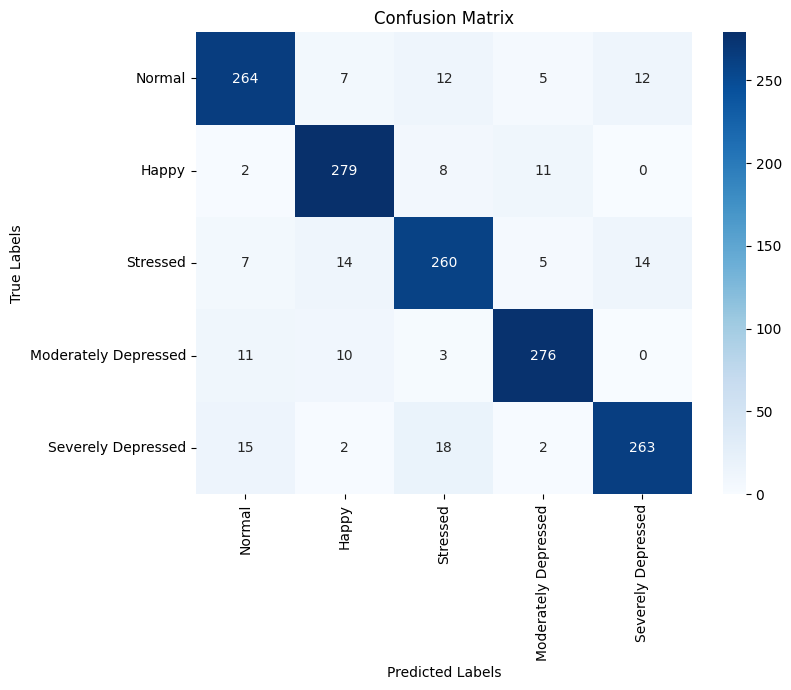

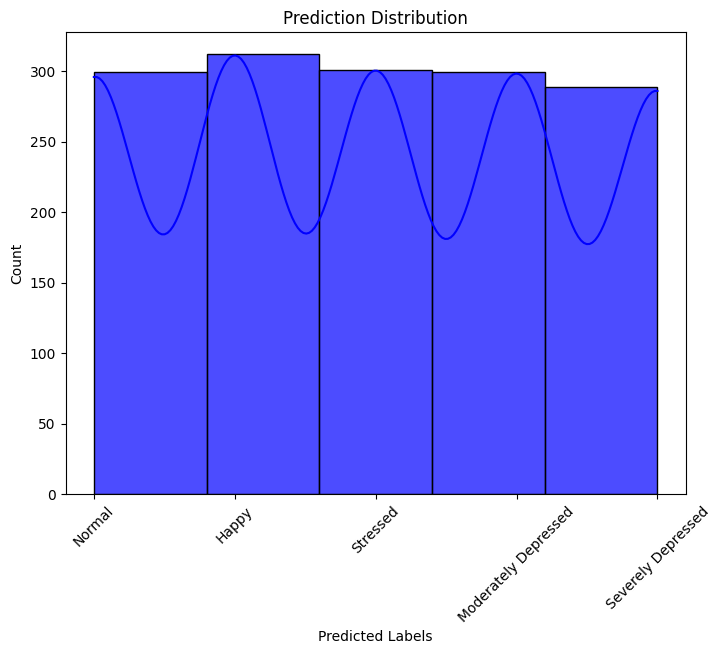

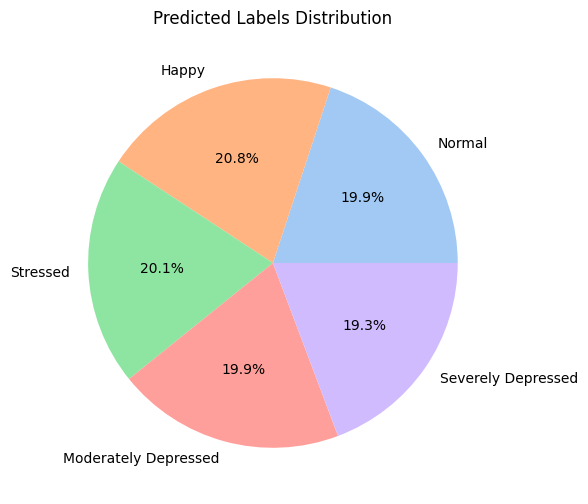

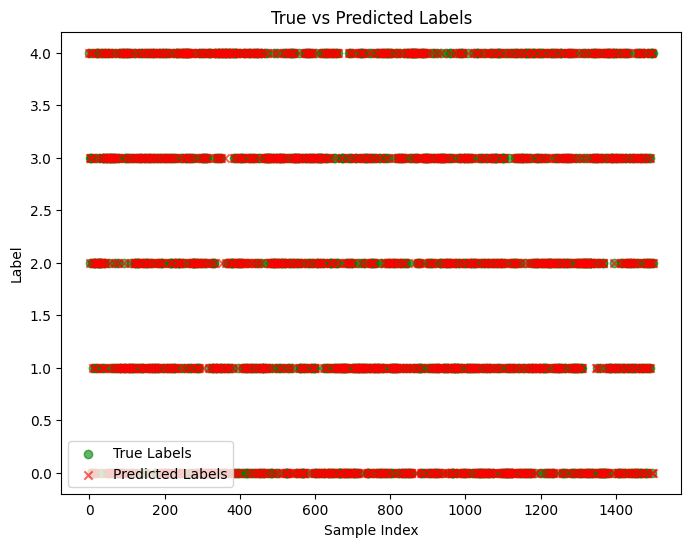

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from safetensors.torch import load_file

# --------------------------
# CONFIGURATIONS
# --------------------------
FINAL_OUTPUT_DIR = "/content/drive/MyDrive/yourpath"  # Path where the model was saved
TEST_DATA_PATH = "/content/drive/MyDrive/0dataset/test_data_balanced.csv"  # Path to test dataset CSV, you can create your own based on the training dataset but make sure both are different

# Mapping labels
label2id = {
    "Normal": 0,
    "Happy": 1,
    "Stressed": 2,
    "Moderately Depressed": 3,
    "Severely Depressed": 4
}
id2label = {v: k for k, v in label2id.items()}

NUM_LABELS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------
# LOAD MODEL & TOKENIZERS
# --------------------------
XLMR_CHECKPOINT = "xlm-roberta-large"
MBERT_CHECKPOINT = "bert-base-multilingual-cased"

tokenizer_xlmr = AutoTokenizer.from_pretrained(FINAL_OUTPUT_DIR)
tokenizer_mbert = AutoTokenizer.from_pretrained(FINAL_OUTPUT_DIR)

class FusionClassifier(nn.Module):
    def __init__(self, xlmr_checkpoint, mbert_checkpoint, num_labels=5, dropout_rate=0.1):
        super(FusionClassifier, self).__init__()
        self.xlmr = AutoModel.from_pretrained(xlmr_checkpoint)
        self.mbert = AutoModel.from_pretrained(mbert_checkpoint)

        self.fc1 = nn.Linear(self.xlmr.config.hidden_size, self.xlmr.config.hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

        combined_size = self.xlmr.config.hidden_size + self.mbert.config.hidden_size
        self.fc2 = nn.Linear(combined_size, num_labels)

    def forward(self, xlmr_input_ids, xlmr_attention_mask, mbert_input_ids, mbert_attention_mask):
        xlmr_outputs = self.xlmr(input_ids=xlmr_input_ids, attention_mask=xlmr_attention_mask)
        xlmr_cls = xlmr_outputs.last_hidden_state[:, 0, :]
        transformed_xlmr = self.relu(self.fc1(xlmr_cls))

        mbert_outputs = self.mbert(input_ids=mbert_input_ids, attention_mask=mbert_attention_mask)
        mbert_mean = torch.mean(mbert_outputs.last_hidden_state, dim=1)

        fused = torch.cat([transformed_xlmr, mbert_mean], dim=1)
        fused = self.dropout(fused)
        logits = self.fc2(fused)

        return logits

# Load model and weights
model = FusionClassifier(XLMR_CHECKPOINT, MBERT_CHECKPOINT, NUM_LABELS)
model.load_state_dict(load_file(os.path.join(FINAL_OUTPUT_DIR, "model.safetensors")))
model.to(DEVICE)
model.eval()

# --------------------------
# LOAD TEST DATA
# --------------------------
df = pd.read_csv(TEST_DATA_PATH).dropna(subset=["caption"]).sample(n=1500, random_state=42)
df["labels"] = df["state"].map(label2id)

# --------------------------
# TOKENIZATION FUNCTION
# --------------------------
def tokenize_function(examples):
    xlmr_enc = tokenizer_xlmr(examples, truncation=True, padding="max_length", max_length=128, return_tensors="pt")
    mbert_enc = tokenizer_mbert(examples, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

    return {
        "xlmr_input_ids": xlmr_enc["input_ids"].to(DEVICE),
        "xlmr_attention_mask": xlmr_enc["attention_mask"].to(DEVICE),
        "mbert_input_ids": mbert_enc["input_ids"].to(DEVICE),
        "mbert_attention_mask": mbert_enc["attention_mask"].to(DEVICE)
    }

# --------------------------
# PREDICTION & METRICS
# --------------------------
y_true = []
y_pred = []

for _, row in df.iterrows():
    tokens = tokenize_function(row["caption"])
    with torch.no_grad():
        logits = model(**tokens)
        pred_label = torch.argmax(logits, dim=-1).cpu().item()

    y_true.append(row["labels"])
    y_pred.append(pred_label)

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall = recall_score(y_true, y_pred, average="macro")
f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# --------------------------
# VISUALIZATIONS
# --------------------------

# Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label2id.keys(), yticklabels=label2id.keys())
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# Histogram of Predictions
plt.figure(figsize=(8,6))
sns.histplot(y_pred, bins=NUM_LABELS, kde=True, color="blue", alpha=0.7)
plt.xticks(ticks=range(NUM_LABELS), labels=list(label2id.keys()), rotation=45)
plt.xlabel("Predicted Labels")
plt.ylabel("Count")
plt.title("Prediction Distribution")
plt.show()

# Pie Chart of Predictions
plt.figure(figsize=(6,6))
unique, counts = np.unique(y_pred, return_counts=True)
plt.pie(counts, labels=[id2label[i] for i in unique], autopct="%1.1f%%", colors=sns.color_palette("pastel"))
plt.title("Predicted Labels Distribution")
plt.show()

# Scatter Plot of Predictions vs Actual
plt.figure(figsize=(8,6))
plt.scatter(range(len(y_true)), y_true, label="True Labels", color="green", marker="o", alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Labels", color="red", marker="x", alpha=0.6)
plt.xlabel("Sample Index")
plt.ylabel("Label")
plt.title("True vs Predicted Labels")
plt.legend()
plt.show()
